# bruteforce

In [676]:
# introduction : definition of bruteforce attack and its carasterictics.

In [677]:
# our mission: analyzing data and creating a powerful ML model capable of predicting brute force attacks.

#phase 1

In [678]:
# our method of dealing with data: we didn't use json because it doesn't provide any related data to bruteforce or network at all, it just gives metadata of sensors.

In [679]:
# fpr pcap files, we used zeek over tshark because it works at a higher, behavioral level rather than raw packets. It automatically extracts security‑relevant events like authentication failures, successes, session durations, and connection metadata, which are exactly what brute‑force attacks are made of. This makes time‑window analysis, noise reduction, and feature extraction much simpler and more reliable. TShark exposes low‑level packet fields, but reconstructing login attempts and attack patterns from them requires heavy manual processing, making Zeek a more natural and scalable choice for brute‑force detection.

In [680]:
# the v1 has all logs merged into one csv "merged_data_V1.csv", and v2 has only the necessary logs for brute force detection 

In [681]:
# ...existing code...
import os, glob
import pandas as pd

def find_zeek_logs(start_dir):
    # 1) cherche dans les dossiers parents
    cur = os.path.abspath(start_dir)
    while True:
        candidate = os.path.join(cur, "zeek_logs")
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    # 2) recherche récursive à partir du répertoire de travail
    candidates = glob.glob(os.path.join(start_dir, "**", "zeek_logs"), recursive=True)
    if candidates:
        return candidates[0]
    return None

cwd = os.getcwd()
print("cwd:", cwd)
base_path = find_zeek_logs(cwd)

if base_path is None:
    print("Erreur: 'zeek_logs' introuvable.")
    print("- Vérifiez où se trouve votre dossier 'zeek_logs'.")
    print("- Vous pouvez changer le répertoire de travail vers le dossier du projet (ex: %cd ..) ou définir base_path en absolu:")
    print(r"  base_path = r'c:\Users\aitou\Documents\projet ai\zeek_logs'")
    raise FileNotFoundError(f"'zeek_logs' not found. cwd={cwd}")

# Each folder corresponds to one device / PCAP
pcap_folders = [f.path for f in os.scandir(base_path) if f.is_dir()]
print("base_path:", base_path, "-> found", len(pcap_folders), "pcap folders")
pcap_folders

# ...existing code...


cwd: c:\Users\aitou\Documents\projet ai\.ipynb_checkpoints
base_path: c:\Users\aitou\Documents\projet ai\zeek_logs -> found 8 pcap folders


['c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-ssh_ap',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-ssh_edge1',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-ssh_mqtt-broker',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-ssh_router',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-ssh_switch',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-telnet_ap',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-telnet_edge1',
 'c:\\Users\\aitou\\Documents\\projet ai\\zeek_logs\\attack_bruteforce_dictionary-telnet_mqtt-broker']

In [682]:
# Each folder corresponds to one device / PCAP
# pcap_folders = [f.path for f in os.scandir(base_path) if f.is_dir()]
# pcap_folders

In [683]:
def read_log_file_json(file_path, log_type, pcap_id, device_type):
    """
    Reads a Zeek JSON log file (.log) and adds metadata columns
    """
    try:
        # Read JSON lines (Zeek JSON logs are usually line-delimited JSON)
        df = pd.read_json(file_path, lines=True)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")
        return pd.DataFrame()
    
    # Add metadata
    df['pcap_id'] = pcap_id
    df['device_type'] = device_type
    df['log_type'] = log_type
    
    return df


In [684]:
example_folder = pcap_folders[0]
device_type = os.path.basename(example_folder)
all_logs = []

for log_file in glob.glob(os.path.join(example_folder, "*.log")):
    log_type = os.path.splitext(os.path.basename(log_file))[0]
    df_log = read_log_file_json(log_file, log_type, pcap_id=device_type, device_type=device_type)
    if not df_log.empty:
        all_logs.append(df_log)

folder_df = pd.concat(all_logs, ignore_index=True)
folder_df.head()



,ts,analyzer_kind,analyzer_name,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,failure_reason,...,host_key_alg,host_key,auth_success,cipher,resumed,established,ssl_history,name,notice,peer
0,1.739537e+09,packet,TEREDO,CwwNM63C3opLA8MFR2,192.168.1.205,38822.0,255.255.255.255,29810.0,udp,Truncated Teredo or invalid inner IP version,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.739537e+09,NaN,NaN,CGxBxl3en6yMbdxKA8,192.168.1.87,50336.0,54.69.37.156,443.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.739537e+09,NaN,NaN,CwzJvg1V59ReXXjaX4,192.168.1.100,39252.0,192.168.1.205,22.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.739537e+09,NaN,NaN,CfFBkf1cfOee8KQDra,192.168.1.102,58918.0,8.8.8.8,53.0,udp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.739537e+09,NaN,NaN,C9LdHVV0aUXR0rvT9,192.168.1.52,43544.0,192.168.1.1,1900.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [685]:
folder_df.describe()

,ts,id.orig_p,id.resp_p,duration,orig_bytes,resp_bytes,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,...,total_bytes,missing_bytes,overflow_bytes,trans_depth,request_body_len,response_body_len,status_code,payload_len,auth_attempts,auth_success
count,2.413000e+03,2412.000000,2412.000000,295.000000,293.000000,293.000000,325.000000,325.000000,325.000000,325.000000,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1838.000000,75.000000,4.0
mean,1.739548e+09,52336.210199,1886.762438,21.303813,15706.634812,37239.204778,0.590769,141.427692,20964.175385,139.870769,...,134.0,0.0,0.0,1.0,0.0,134.0,404.0,4.844396,0.346667,0.0
std,5.348213e+05,7873.278583,3254.432565,40.669371,32273.205074,75872.531500,7.519229,285.587588,42829.427294,286.627606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.234774,1.474956,0.0
min,1.739537e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,134.0,0.0,0.0,1.0,0.0,134.0,404.0,0.000000,0.000000,0.0
25%,1.739537e+09,50692.000000,1883.000000,0.023856,44.000000,44.000000,0.000000,1.000000,72.000000,1.000000,...,134.0,0.0,0.0,1.0,0.0,134.0,404.0,2.000000,0.000000,0.0
50%,1.739537e+09,52268.000000,1883.000000,0.025027,44.000000,44.000000,0.000000,1.000000,72.000000,1.000000,...,134.0,0.0,0.0,1.0,0.0,134.0,404.0,3.000000,0.000000,0.0
75%,1.739537e+09,55866.000000,1883.000000,7.803232,4512.000000,1018.000000,0.000000,24.000000,4800.000000,11.000000,...,134.0,0.0,0.0,1.0,0.0,134.0,404.0,5.000000,0.000000,0.0
max,1.765808e+09,64829.000000,53611.000000,121.569801,270938.000000,194730.000000,96.000000,772.000000,137724.000000,780.000000,...,134.0,0.0,0.0,1.0,0.0,134.0,404.0,16.000000,7.000000,0.0


In [686]:
all_folders_dfs = []

for folder in pcap_folders:
    device_type = os.path.basename(folder)
    folder_logs = []
    
    for log_file in glob.glob(os.path.join(folder, "*.log")):
        log_type = os.path.splitext(os.path.basename(log_file))[0]
        df_log = read_log_file_json(log_file, log_type, pcap_id=device_type, device_type=device_type)
        if not df_log.empty:
            folder_logs.append(df_log)
    
    if folder_logs:
        folder_df = pd.concat(folder_logs, ignore_index=True)
        all_folders_dfs.append(folder_df)

master_df = pd.concat(all_folders_dfs, ignore_index=True)
master_df.head()


,ts,analyzer_kind,analyzer_name,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,failure_reason,...,certificate.key_alg,certificate.sig_alg,certificate.key_type,certificate.key_length,certificate.exponent,host_cert,client_cert,san.dns,basic_constraints.ca,basic_constraints.path_len
0,1.739537e+09,packet,TEREDO,CwwNM63C3opLA8MFR2,192.168.1.205,38822.0,255.255.255.255,29810.0,udp,Truncated Teredo or invalid inner IP version,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.739537e+09,NaN,NaN,CGxBxl3en6yMbdxKA8,192.168.1.87,50336.0,54.69.37.156,443.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.739537e+09,NaN,NaN,CwzJvg1V59ReXXjaX4,192.168.1.100,39252.0,192.168.1.205,22.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.739537e+09,NaN,NaN,CfFBkf1cfOee8KQDra,192.168.1.102,58918.0,8.8.8.8,53.0,udp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.739537e+09,NaN,NaN,C9LdHVV0aUXR0rvT9,192.168.1.52,43544.0,192.168.1.1,1900.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [687]:
master_df.to_csv(output_csv, index=False)
print(f"Merged CSV saved to {output_csv}")


Merged CSV saved to merged_data_V2.csv


In [688]:
master_df.shape

(35988, 130)

In [689]:
master_df.head()

,ts,analyzer_kind,analyzer_name,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,failure_reason,...,certificate.key_alg,certificate.sig_alg,certificate.key_type,certificate.key_length,certificate.exponent,host_cert,client_cert,san.dns,basic_constraints.ca,basic_constraints.path_len
0,1.739537e+09,packet,TEREDO,CwwNM63C3opLA8MFR2,192.168.1.205,38822.0,255.255.255.255,29810.0,udp,Truncated Teredo or invalid inner IP version,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.739537e+09,NaN,NaN,CGxBxl3en6yMbdxKA8,192.168.1.87,50336.0,54.69.37.156,443.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.739537e+09,NaN,NaN,CwzJvg1V59ReXXjaX4,192.168.1.100,39252.0,192.168.1.205,22.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.739537e+09,NaN,NaN,CfFBkf1cfOee8KQDra,192.168.1.102,58918.0,8.8.8.8,53.0,udp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.739537e+09,NaN,NaN,C9LdHVV0aUXR0rvT9,192.168.1.52,43544.0,192.168.1.1,1900.0,tcp,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [690]:
# V2:

In [691]:
BRUTEFORCE_LOG_TYPES = {
    "ssh",
    "conn",
    "http",
    "mqtt_publish"
}


In [692]:
def read_json_log(file_path, pcap_id, device_type):
    log_type = os.path.splitext(os.path.basename(file_path))[0]

    # Skip non–bruteforce logs early
    if log_type not in BRUTEFORCE_LOG_TYPES:
        return None

    try:
        df = pd.read_json(file_path, lines=True)
    except Exception as e:
        print(f"[!] Failed to read {file_path}: {e}")
        return None

    # Metadata
    df["pcap_id"] = pcap_id
    df["device_type"] = device_type
    df["log_type"] = log_type

    return df


In [693]:
bf_logs = []

for folder in pcap_folders:
    device_type = os.path.basename(folder)
    pcap_id = device_type  # or use another naming scheme

    for log_file in glob.glob(os.path.join(folder, "*.log")):
        df = read_json_log(log_file, pcap_id, device_type)
        if df is not None and not df.empty:
            bf_logs.append(df)

len(bf_logs)


27

In [694]:
bf_df = pd.concat(bf_logs, ignore_index=True)

bf_df.shape


(34578, 53)

In [695]:
bf_df["log_type"].value_counts()


log_type
mqtt_publish    28246
conn             6168
ssh               133
http               31
Name: count, dtype: int64

In [696]:
output_csv = "merged_data_V2.csv"

bf_df.to_csv(output_csv, index=False)

import os
print("Saved to:", os.path.abspath(output_csv))


Saved to: c:\Users\aitou\Documents\projet ai\.ipynb_checkpoints\merged_data_V2.csv


## Phase 2: 


Authors: Meryem Cherkaoui & Hajar Ait- Ouarab.

In the Exploratory Data Analysis (EDA) phase, we aim to thoroughly understand the structure, quality, and behavioral patterns of the network traffic dataset used for brute force attack detection. This phase begins with a global inspection of the data, including its dimensionality, data types, and the presence of missing values. We then perform a light data cleaning process to handle incomplete or inconsistent entries while preserving potentially meaningful anomalies. Temporal analysis is conducted to study traffic evolution over time and to identify abnormal activity bursts that may indicate automated brute force attempts. Furthermore, we analyze source IP addresses, destination ports, and services to detect highly repetitive connection patterns and frequently targeted services. Connection states, traffic volume, and session duration are also examined to distinguish failed authentication attempts from normal connections. Through statistical analysis and informative visualizations, we identify outliers and suspicious behaviors, and we engineer preliminary features that highlight brute force characteristics. Overall, the EDA phase provides critical insights that guide feature selection, anomaly detection strategies, and the development of robust machine learning models in later stages of the project.

In [697]:
#Visualisation

In [698]:
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive Visualization
import plotly.express as px
import plotly.graph_objects as go

# Warning Management
import warnings
warnings.filterwarnings("ignore")

# Visual Settings (ou Plotting Parameters)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [699]:
df = pd.read_csv("merged_data_V2.csv")
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,duration,orig_bytes,resp_bytes,...,auth_attempts,client,server,cipher_alg,mac_alg,compression_alg,kex_alg,host_key_alg,host_key,auth_success
0,1.739537e+09,CGxBxl3en6yMbdxKA8,192.168.1.87,50336,54.69.37.156,443,tcp,0.116701,0.0,389.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.739537e+09,CwzJvg1V59ReXXjaX4,192.168.1.100,39252,192.168.1.205,22,tcp,0.141500,1302.0,1018.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.739537e+09,CfFBkf1cfOee8KQDra,192.168.1.102,58918,8.8.8.8,53,udp,0.024259,32.0,107.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.739537e+09,C9LdHVV0aUXR0rvT9,192.168.1.52,43544,192.168.1.1,1900,tcp,0.005341,60.0,279.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.739537e+09,CqBZme1GGnrbj6tdG9,192.168.1.205,52487,8.8.4.4,53,udp,0.023983,44.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [700]:
df.shape

(34578, 53)

In [701]:
# Convert Unix timestamp (seconds) to readable datetime format
df['ts'] = pd.to_datetime(df['ts'], unit='s')

# Sort the dataset chronologically by timestamp
df = df.sort_values(by='ts')
#add new columns for hour and day of week
df['hour'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.day_name()
df['is_night'] = df['hour'].between(0, 6)



In [702]:
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,duration,orig_bytes,resp_bytes,...,cipher_alg,mac_alg,compression_alg,kex_alg,host_key_alg,host_key,auth_success,hour,day_of_week,is_night
24624,2025-02-13 20:09:40.849479914,CStZM495Bi0yks39i,192.168.1.87,49154,255.255.255.255,6667,udp,301.548325,8772.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,Thursday,False
24636,2025-02-13 20:09:40.968379021,CaeCVPMs3WkmSmUBb,192.168.1.88,49155,255.255.255.255,6667,udp,297.996160,10148.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,Thursday,False
24639,2025-02-13 20:09:40.980211020,CIFd7p2odaxOCJ8Cw6,192.168.1.83,40463,35.84.67.65,8886,tcp,242.685527,345.0,345.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,Thursday,False
24670,2025-02-13 20:09:41.119806051,C3QYjPedokLwvR8u3,192.168.1.15,56304,192.168.1.193,1883,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,Thursday,False
24627,2025-02-13 20:09:41.119806051,C3QYjPedokLwvR8u3,192.168.1.15,56304,192.168.1.193,1883,tcp,301.332054,12942.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,Thursday,False


In [703]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34578 entries, 24624 to 24160
Data columns (total 56 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ts                 34578 non-null  datetime64[ns]
 1   uid                34578 non-null  object        
 2   id.orig_h          34578 non-null  object        
 3   id.orig_p          34578 non-null  int64         
 4   id.resp_h          34578 non-null  object        
 5   id.resp_p          34578 non-null  int64         
 6   proto              6168 non-null   object        
 7   duration           4934 non-null   float64       
 8   orig_bytes         4934 non-null   float64       
 9   resp_bytes         4934 non-null   float64       
 10  conn_state         6168 non-null   object        
 11  local_orig         6168 non-null   object        
 12  local_resp         6168 non-null   object        
 13  missed_bytes       6168 non-null   float64       
 14  history

In [704]:
df.describe()

,ts,id.orig_p,id.resp_p,duration,orig_bytes,resp_bytes,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,...,ip_proto,trans_depth,version,request_body_len,response_body_len,status_code,payload_len,auth_attempts,auth_success,hour
count,34578,34578.00000,34578.000000,4.934000e+03,4934.000000,4934.000000,6168.000000,6168.000000,6168.000000,6168.000000,...,6168.000000,31.0,164.000000,31.0,31.0,31.0,28246.000000,133.000000,60.0,34578.000000
mean,2025-02-14 06:24:03.464133376,52533.63523,1874.921366,2.076089e+01,2266.545197,2363.378597,0.828794,16.759403,2250.419423,15.067445,...,8.724546,1.0,1.829878,0.0,134.0,404.0,4.847837,2.278195,0.0,12.868674
min,2025-02-13 20:09:40.849479914,0.00000,0.000000,9.536743e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.0,1.100000,0.0,134.0,404.0,0.000000,0.000000,0.0,3.000000
25%,2025-02-13 20:19:20.721399552,50692.00000,1883.000000,4.820824e-04,0.000000,0.000000,0.000000,1.000000,60.000000,1.000000,...,6.000000,1.0,2.000000,0.0,134.0,404.0,2.000000,0.000000,0.0,3.000000
50%,2025-02-14 03:28:20.019486720,52459.00000,1883.000000,7.030964e-04,0.000000,0.000000,0.000000,1.000000,60.000000,1.000000,...,6.000000,1.0,2.000000,0.0,134.0,404.0,3.000000,0.000000,0.0,12.000000
75%,2025-02-14 12:48:00.832565760,55866.00000,1883.000000,2.384168e-02,44.000000,0.000000,0.000000,1.000000,72.000000,1.000000,...,17.000000,1.0,2.000000,0.0,134.0,404.0,5.000000,5.000000,0.0,20.000000
max,2025-02-14 18:58:44.351233959,65350.00000,59995.000000,3.017096e+02,671993.000000,194730.000000,2460.000000,797.000000,372755.000000,800.000000,...,58.000000,1.0,2.000000,0.0,134.0,404.0,16.000000,7.000000,0.0,20.000000
std,NaN,8204.67266,3008.190249,6.620580e+01,23711.846143,20563.123520,44.326931,87.229019,15294.240420,87.318734,...,5.178585,0.0,0.353454,0.0,0.0,0.0,4.229142,2.541633,0.0,6.978652


In [705]:
df.columns

Index(['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
       'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state',
       'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts',
       'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'ip_proto', 'service',
       'pcap_id', 'device_type', 'log_type', 'trans_depth', 'method', 'host',
       'uri', 'version', 'request_body_len', 'response_body_len',
       'status_code', 'status_msg', 'tags', 'resp_fuids', 'resp_mime_types',
       'from_client', 'retain', 'qos', 'status', 'topic', 'payload',
       'payload_len', 'auth_attempts', 'client', 'server', 'cipher_alg',
       'mac_alg', 'compression_alg', 'kex_alg', 'host_key_alg', 'host_key',
       'auth_success', 'hour', 'day_of_week', 'is_night'],
      dtype='object')

In [706]:
df.dtypes

ts                   datetime64[ns]
uid                          object
id.orig_h                    object
id.orig_p                     int64
id.resp_h                    object
id.resp_p                     int64
proto                        object
duration                    float64
orig_bytes                  float64
resp_bytes                  float64
conn_state                   object
local_orig                   object
local_resp                   object
missed_bytes                float64
history                      object
orig_pkts                   float64
orig_ip_bytes               float64
resp_pkts                   float64
resp_ip_bytes               float64
ip_proto                    float64
service                      object
pcap_id                      object
device_type                  object
log_type                     object
trans_depth                 float64
method                       object
host                         object
uri                         

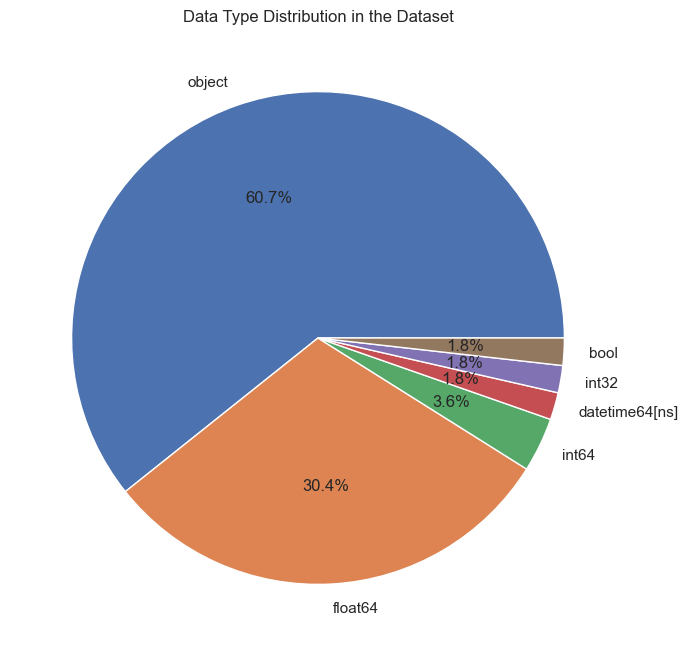

In [707]:
# Count the number of columns per data type
df.dtypes.value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))

# Set the chart title and labels
plt.title('Data Type Distribution in the Dataset')
plt.ylabel('')
plt.show()

In [708]:
df.duplicated().sum()

np.int64(0)

In [709]:
df.isna().sum()

ts                       0
uid                      0
id.orig_h                0
id.orig_p                0
id.resp_h                0
id.resp_p                0
proto                28410
duration             29644
orig_bytes           29644
resp_bytes           29644
conn_state           28410
local_orig           28410
local_resp           28410
missed_bytes         28410
history              28698
orig_pkts            28410
orig_ip_bytes        28410
resp_pkts            28410
resp_ip_bytes        28410
ip_proto             28410
service              32994
pcap_id                  0
device_type              0
log_type                 0
trans_depth          34547
method               34547
host                 34547
uri                  34547
version              34414
request_body_len     34547
response_body_len    34547
status_code          34547
status_msg           34547
tags                 34547
resp_fuids           34547
resp_mime_types      34547
from_client           6332
r

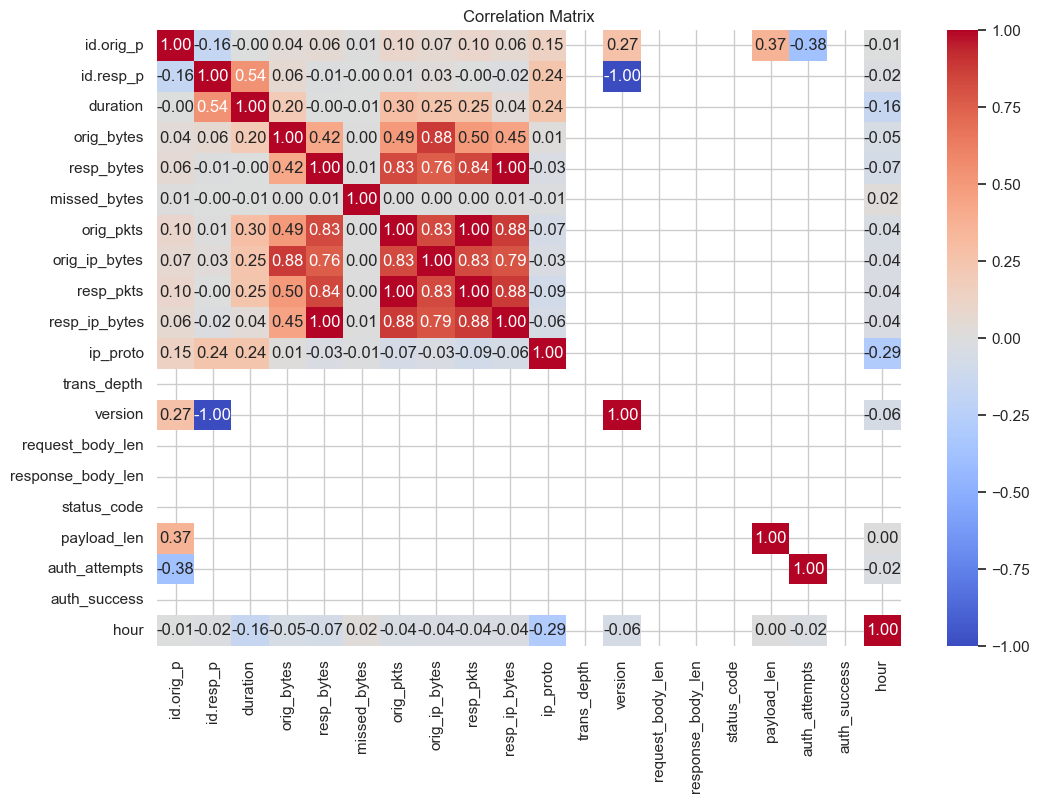

In [710]:
# 1. Select only numeric columns
df__numeric = df.select_dtypes(include=[np.number])

# 2. Calculate the correlation on df_numeric
corr = df__numeric.corr()

# 3. Display the heatmap
plt.figure(figsize=(12, 8)) # Optional: to enlarge the figure
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

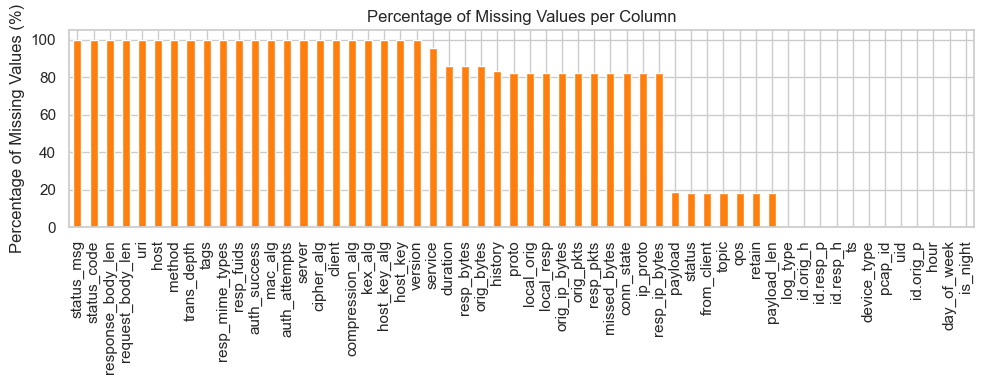

In [711]:
_mdf = df.copy()

# Calculate the percentage of missing values per column
miss_pct = _mdf.isna().mean() * 100

plt.figure(figsize=(10,4))
miss_pct.sort_values(ascending=False).plot(kind="bar", color="tab:orange")

# Set axis labels and chart title
plt.ylabel("Percentage of Missing Values (%)")
plt.title("Percentage of Missing Values per Column")

plt.tight_layout()
plt.show()

In [712]:
# 99.9% Threshold: drop columns if they have more than 99.9% missing values
threshold = 0.999

# Calculate the percentage of missing values
miss_pct = df.isna().mean()

# Select columns to keep (those below the threshold)
useful_columns = miss_pct[miss_pct <= threshold].index

# Create the new filtered DataFrame
df1 = df[useful_columns]

# Print the results
print(f"Initial columns: {df.shape[1]}")
print(f"Retained columns: {df1.shape[1]}")

Initial columns: 56
Retained columns: 45


In [728]:
cols_eda = [
    'ts', 'uid', 'id.orig_h', 'id.resp_p', 'service', 
    'duration', 'conn_state', 'history', 
    'orig_pkts', 'resp_pkts', 'orig_ip_bytes','log_type', 'resp_ip_bytes','hour','is_night',
]

df1 = df[cols_eda].copy()

In [714]:
df1.head()

,ts,uid,id.orig_h,id.resp_p,service,duration,conn_state,history,orig_pkts,resp_pkts,orig_ip_bytes,log_type,resp_ip_bytes,hour,is_night
24624,2025-02-13 20:09:40.849479914,CStZM495Bi0yks39i,192.168.1.87,6667,NaN,301.548325,S0,D,51.0,0.0,10200.0,conn,0.0,20,False
24636,2025-02-13 20:09:40.968379021,CaeCVPMs3WkmSmUBb,192.168.1.88,6667,NaN,297.996160,S0,D,59.0,0.0,11800.0,conn,0.0,20,False
24639,2025-02-13 20:09:40.980211020,CIFd7p2odaxOCJ8Cw6,192.168.1.83,8886,NaN,242.685527,OTH,DdA,10.0,5.0,745.0,conn,545.0,20,False
24670,2025-02-13 20:09:41.119806051,C3QYjPedokLwvR8u3,192.168.1.15,1883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mqtt_publish,NaN,20,False
24627,2025-02-13 20:09:41.119806051,C3QYjPedokLwvR8u3,192.168.1.15,1883,mqtt,301.332054,OTH,DadA,607.0,607.0,37222.0,conn,24290.0,20,False


In [715]:
# True if NaN, False otherwise
df1.isna().sum()

ts                   0
uid                  0
id.orig_h            0
id.resp_p            0
service          32994
duration         29644
conn_state       28410
history          28698
orig_pkts        28410
resp_pkts        28410
orig_ip_bytes    28410
log_type             0
resp_ip_bytes    28410
hour                 0
is_night             0
dtype: int64

In [716]:
# Handle missing values for numerical columns by filling them with 0
num_cols = ["duration", "orig_pkts", "resp_pkts", "orig_ip_bytes", "resp_ip_bytes"]
for col in num_cols:
    df1[col] = df1[col].fillna(0)

# Handle missing values for categorical columns by labeling them as "unknown"
df1["service"] = df1["service"].fillna("unknown")
df1["conn_state"] = df1["conn_state"].fillna("unknown")
df1["history"] = df1["history"].fillna("unknown")


In [717]:
df1.isna().sum()

ts               0
uid              0
id.orig_h        0
id.resp_p        0
service          0
duration         0
conn_state       0
history          0
orig_pkts        0
resp_pkts        0
orig_ip_bytes    0
log_type         0
resp_ip_bytes    0
hour             0
is_night         0
dtype: int64

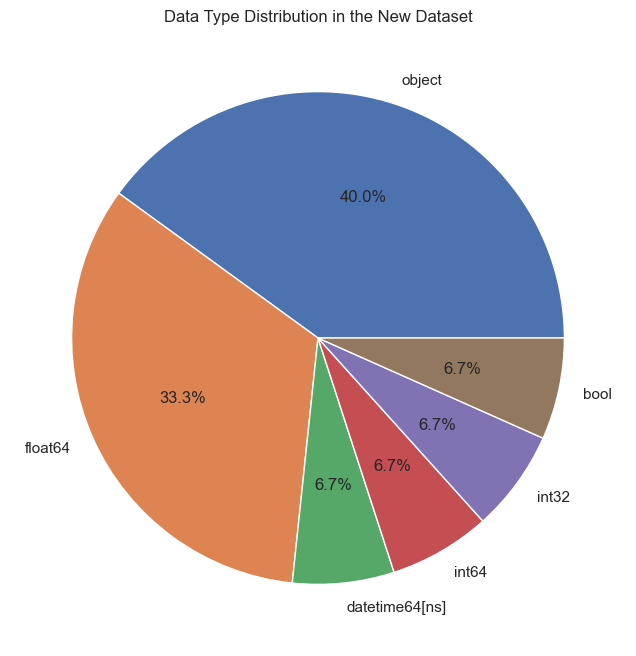

In [718]:
# Plot the distribution of data types in the cleaned dataset
df1.dtypes.value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))

# Set the chart title and remove the y-axis label
plt.title('Data Type Distribution in the New Dataset')
plt.ylabel('')

plt.show()

<Axes: xlabel='service'>

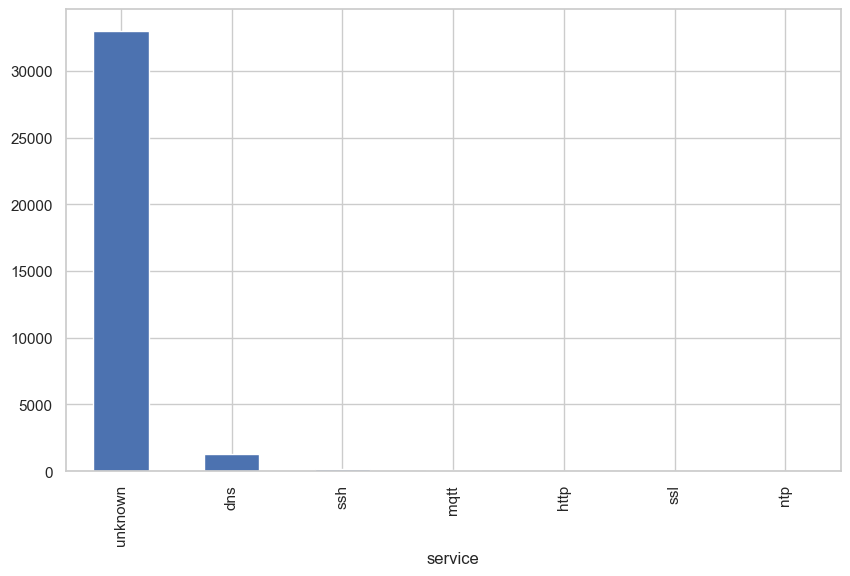

In [719]:
# Duration by service (boxplot)
df1['service'].value_counts().plot(kind='bar')

In [720]:
# Selection of numeric columns
numeric_cols = df1.select_dtypes(include='number').columns

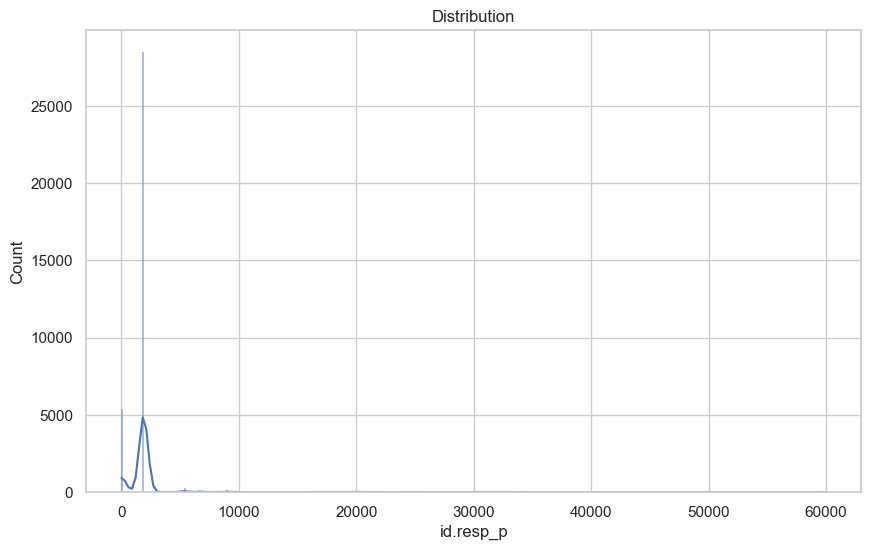

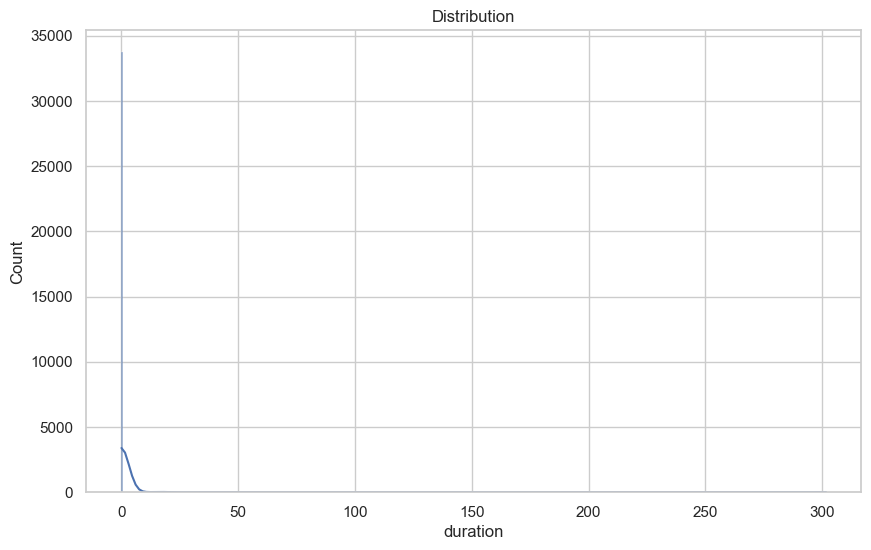

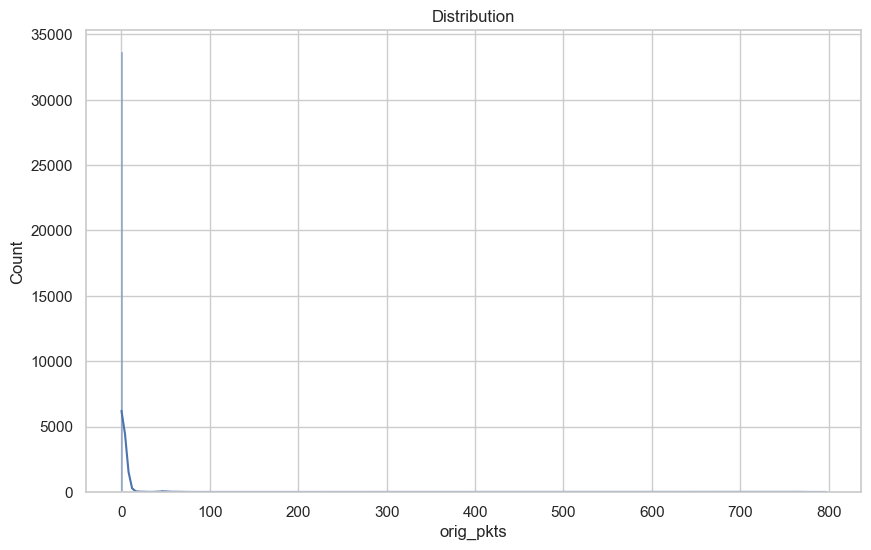

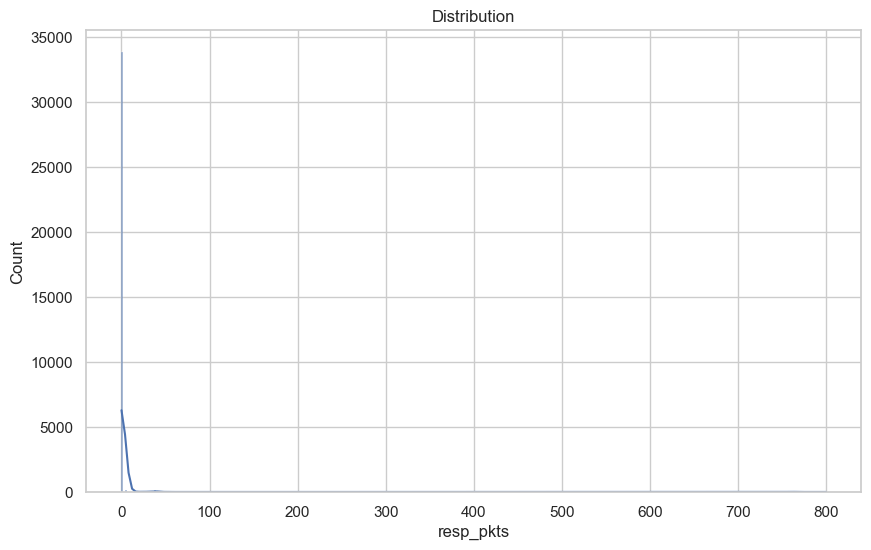

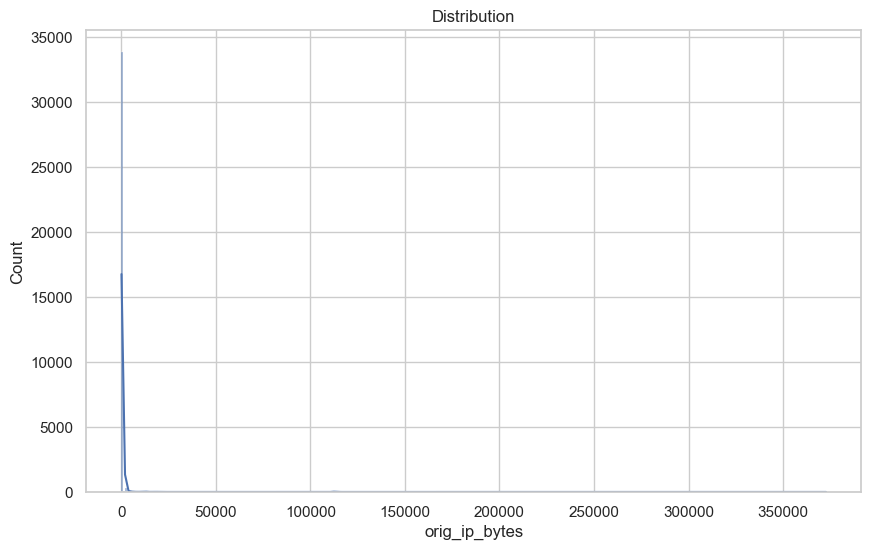

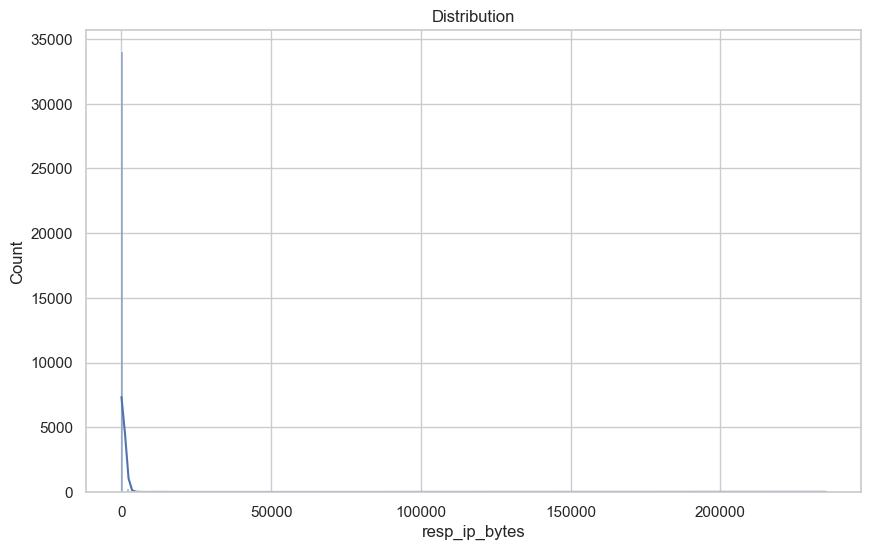

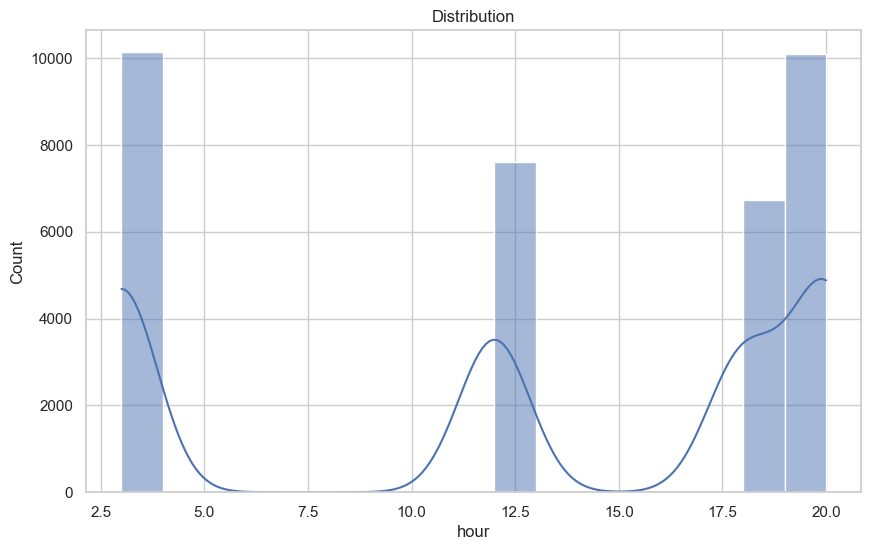

In [721]:
# Plot distributions for each numeric column
for i in numeric_cols:
    sns.histplot(df1[i], kde=True)
    plt.title("Distribution")
    plt.show()

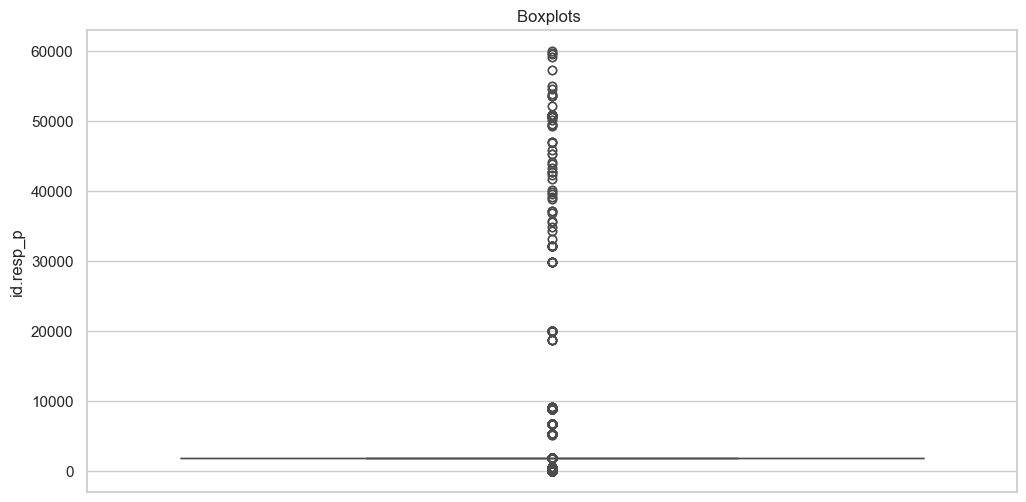

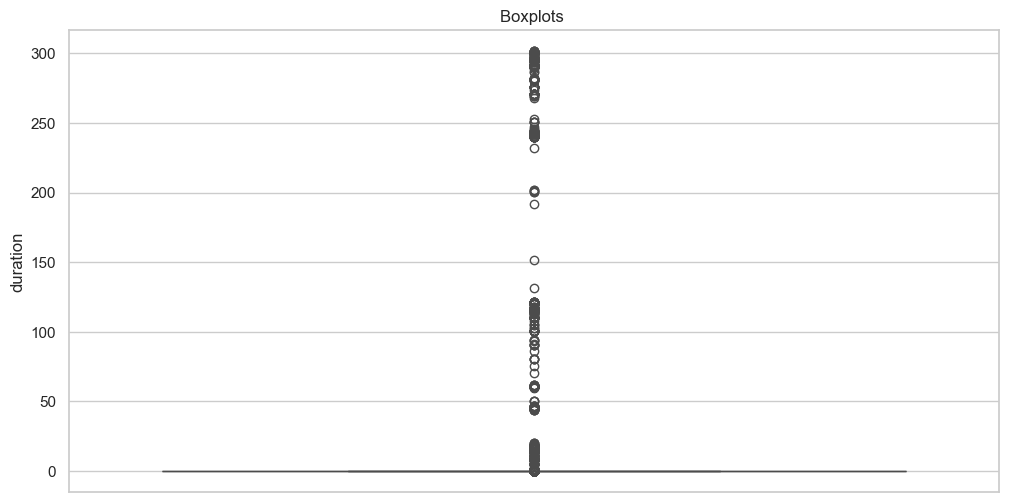

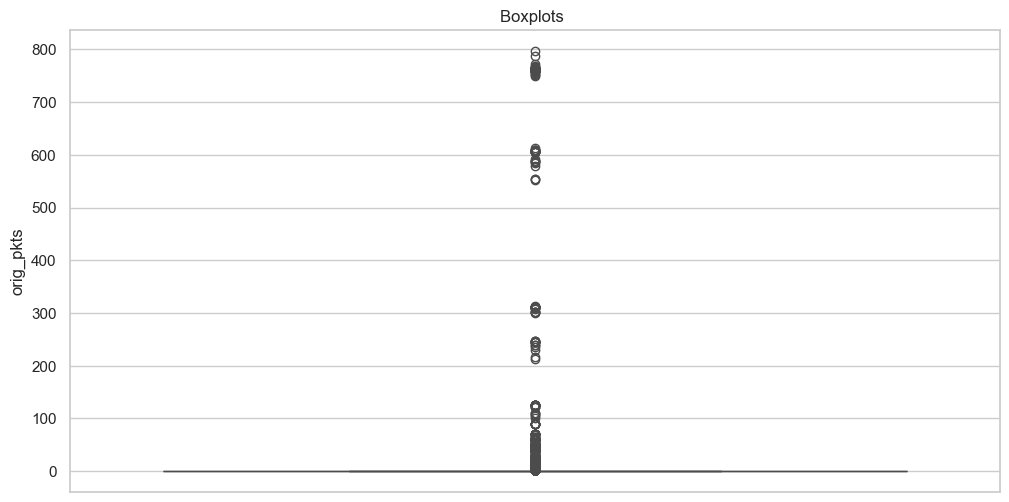

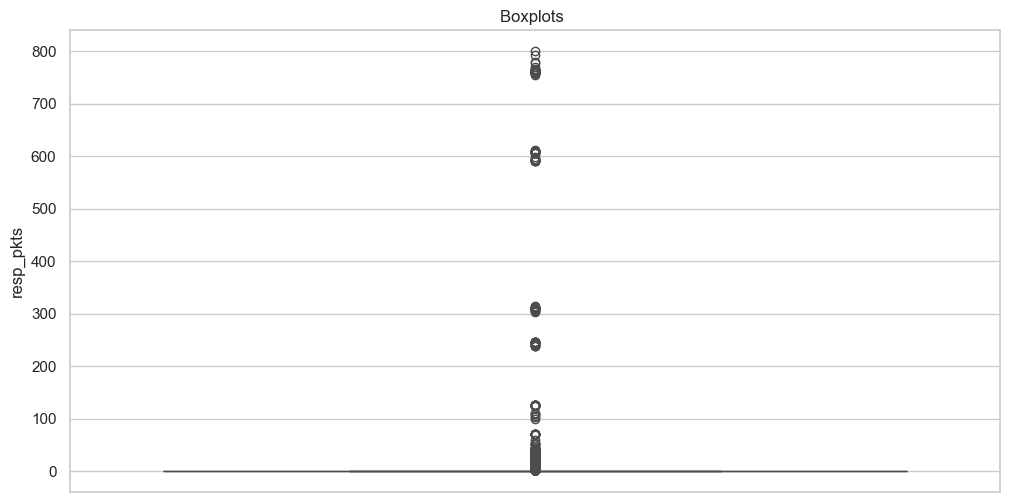

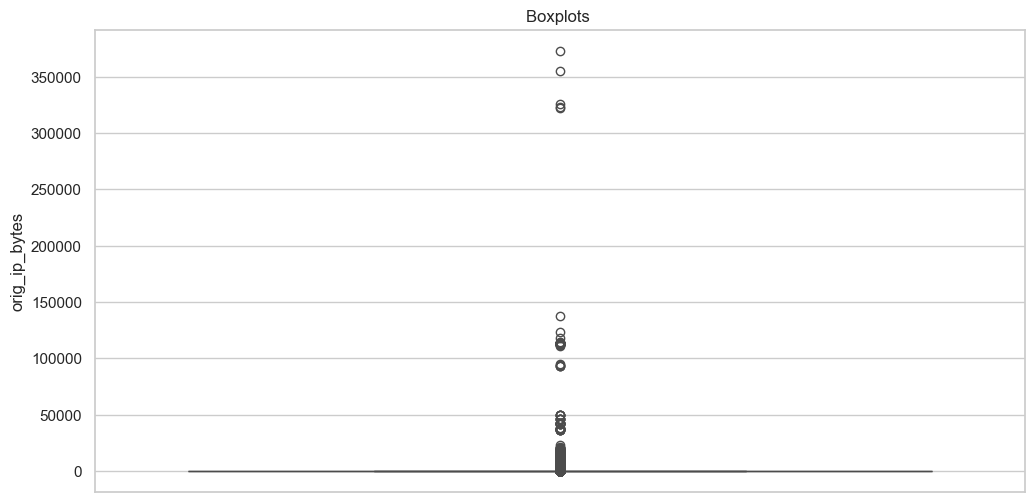

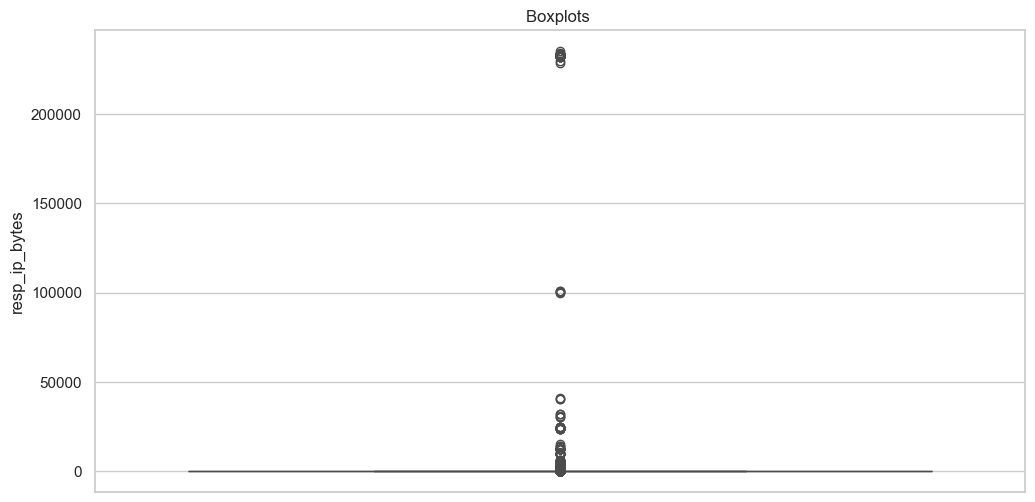

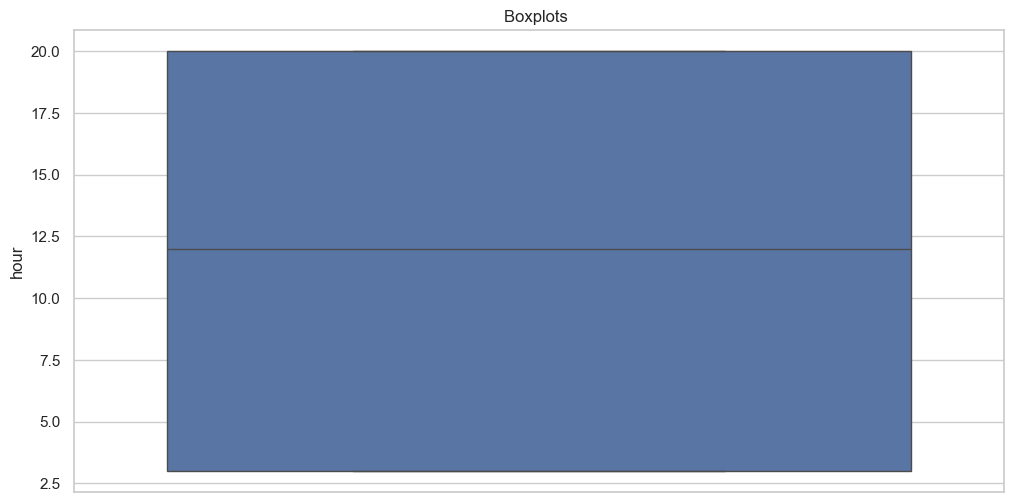

In [722]:
# Boxplots for each numeric column
for i in numeric_cols:
    plt.figure(figsize=(12,6))
    sns.boxplot(df1[i])
    plt.title("Boxplots ")
    plt.xticks(rotation=45)  
    plt.show()

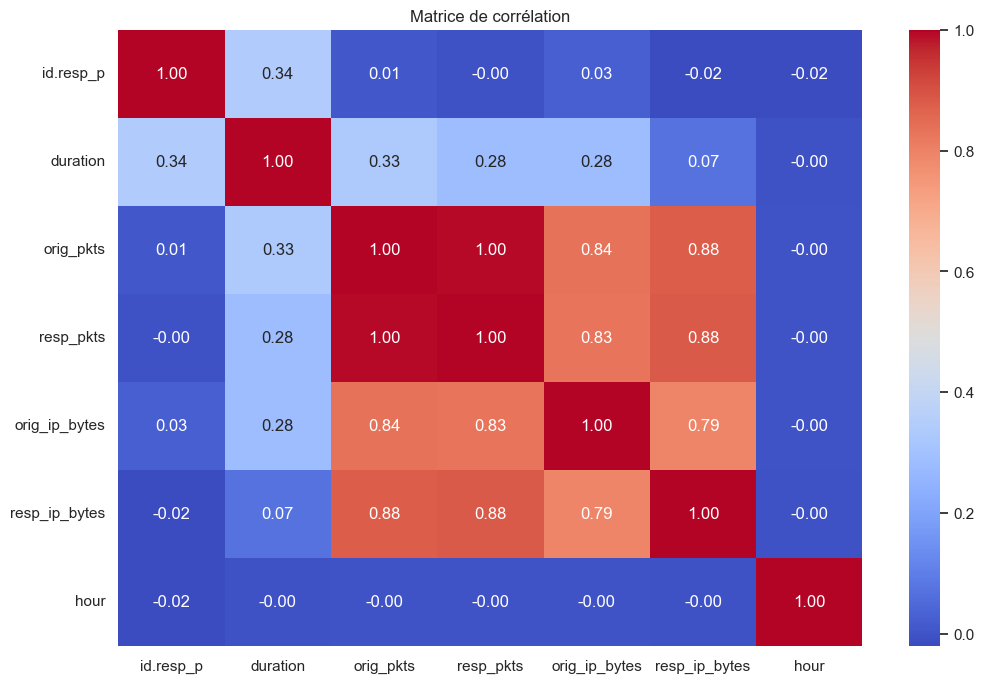

In [723]:
# selection of numeric columns
df_numeric = df1.select_dtypes(include=[np.number])

#calculate the correlation on df_numeric (and not df1)
corr = df_numeric.corr()

# show correlation heatmap
plt.figure(figsize=(12, 8)) # Optional: to enlarge the figure
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

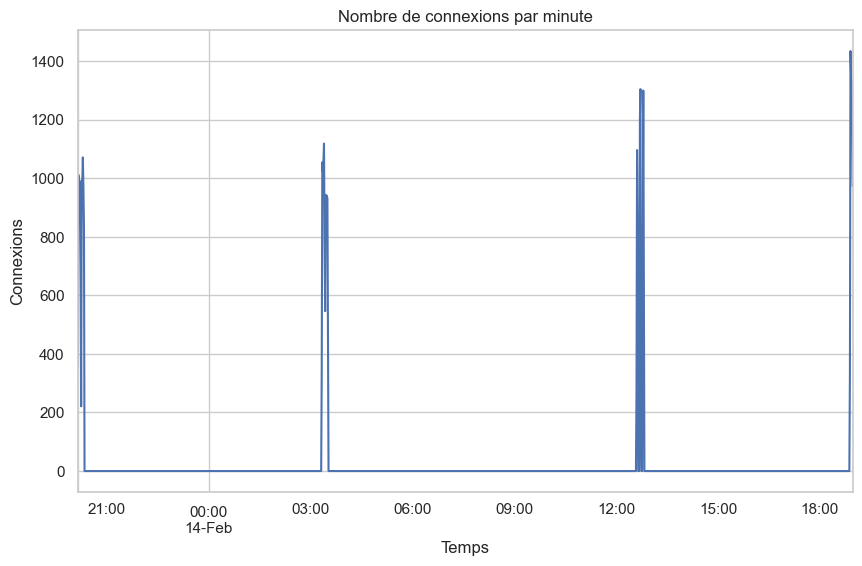

In [724]:
#Number of connections per minute
df1.set_index("ts", inplace=True)

connections_per_min = df1.resample("1min").size()

connections_per_min.plot()
plt.title("Nombre de connexions par minute")
plt.xlabel("Temps")
plt.ylabel("Connexions")
plt.show()


In [725]:
#Identify highest traffic peaks
connections_per_min.sort_values(ascending=False).head(10)

ts
2025-02-14 18:54:00    1434
2025-02-14 18:55:00    1359
2025-02-14 18:56:00    1331
2025-02-14 12:43:00    1304
2025-02-14 18:57:00    1302
2025-02-14 12:48:00    1299
2025-02-14 12:42:00    1203
2025-02-14 03:24:00    1118
2025-02-14 12:37:00    1096
2025-02-13 20:18:00    1071
dtype: int64

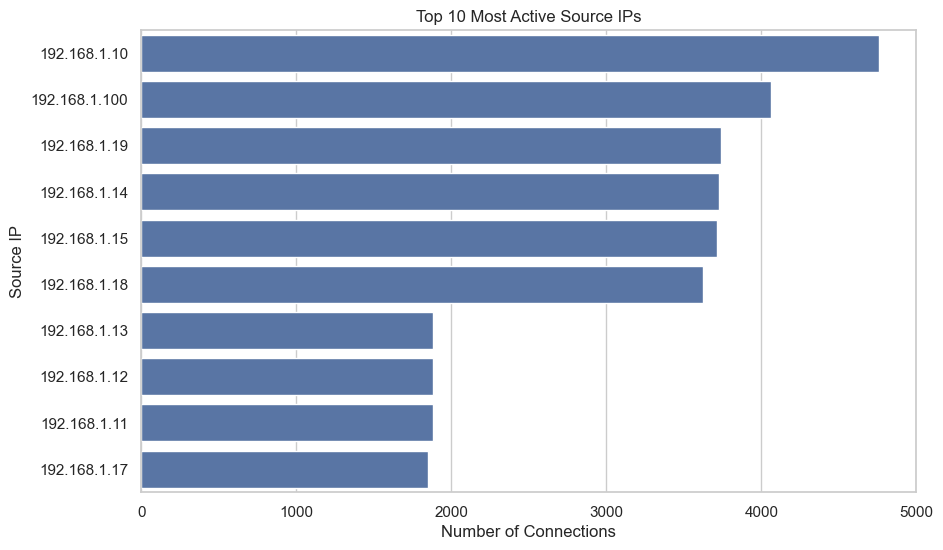

In [726]:
#Top 10 most active source IPs
top_ips = df1["id.orig_h"].value_counts().head(10)

sns.barplot(x=top_ips.values, y=top_ips.index)
plt.title("Top 10 Most Active Source IPs")
plt.xlabel("Number of Connections")
plt.ylabel("Source IP")
plt.show()

<Axes: xlabel='ts'>

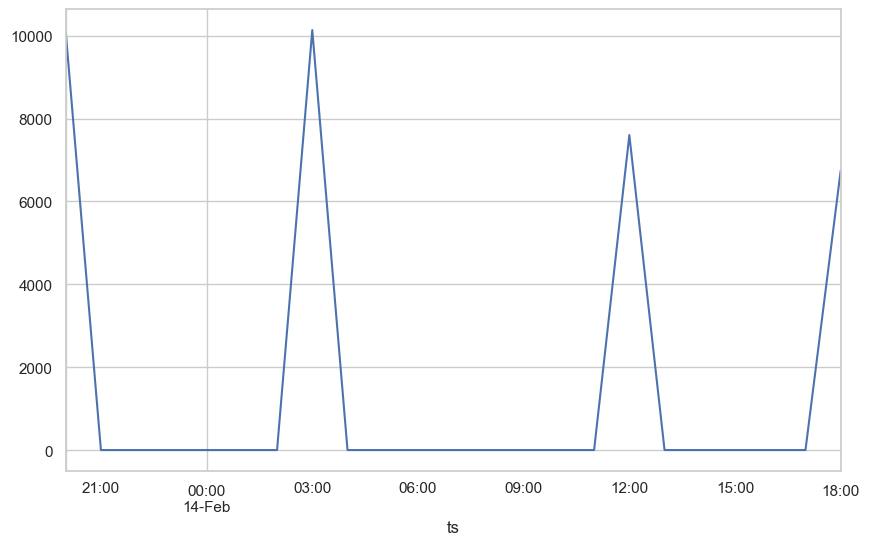

In [729]:
# Hourly activity trend
df1.set_index('ts').resample('1H').size().plot()


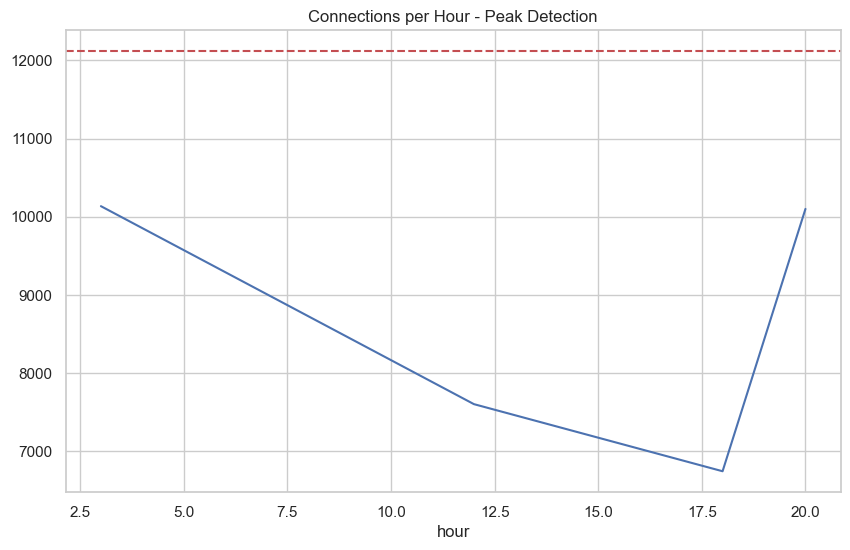

In [ ]:
# Identify hourly connection peaks
hourly_conn = df1.groupby('hour').size()
hourly_conn.plot(title='Connections per Hour - Peak Detection')
plt.axhline(y=hourly_conn.mean() + 2*hourly_conn.std(), color='r', linestyle='--', label='Seuil anomalie')

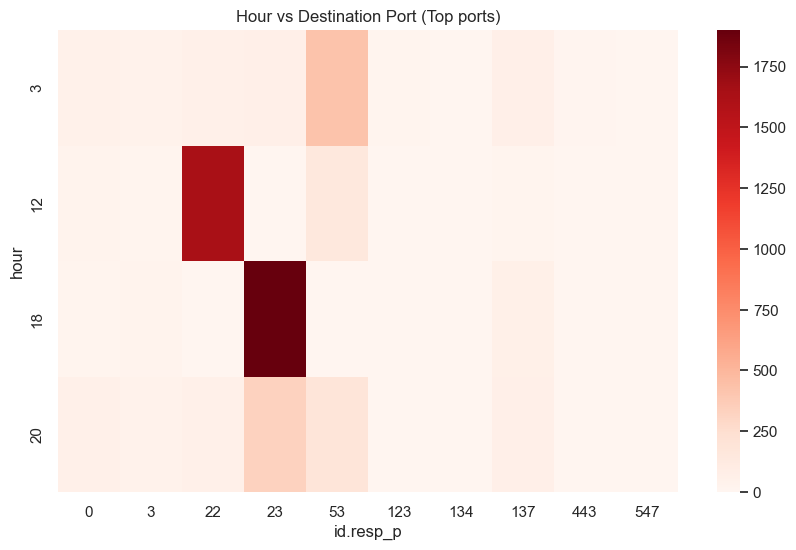

In [ ]:
#Targeted attacks on a specific port at specific times.

hour_port = pd.crosstab(df1['hour'], df1['id.resp_p'])
sns.heatmap(hour_port.iloc[:, :10], cmap='Reds')
plt.title("Hour vs Destination Port (Top ports)")
plt.show()


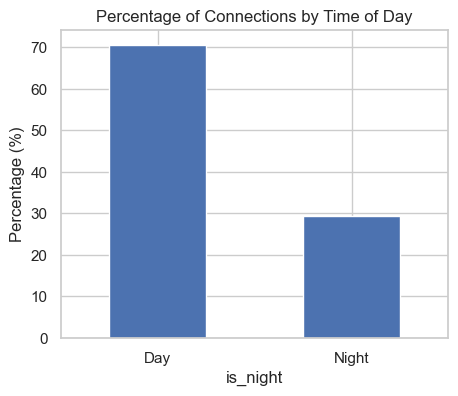

In [730]:
percent = df1['is_night'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(5,4))
percent.plot(kind='bar')
plt.xticks([0, 1], ['Day', 'Night'], rotation=0)
plt.ylabel('Percentage (%)')
plt.title('Percentage of Connections by Time of Day')
plt.show()


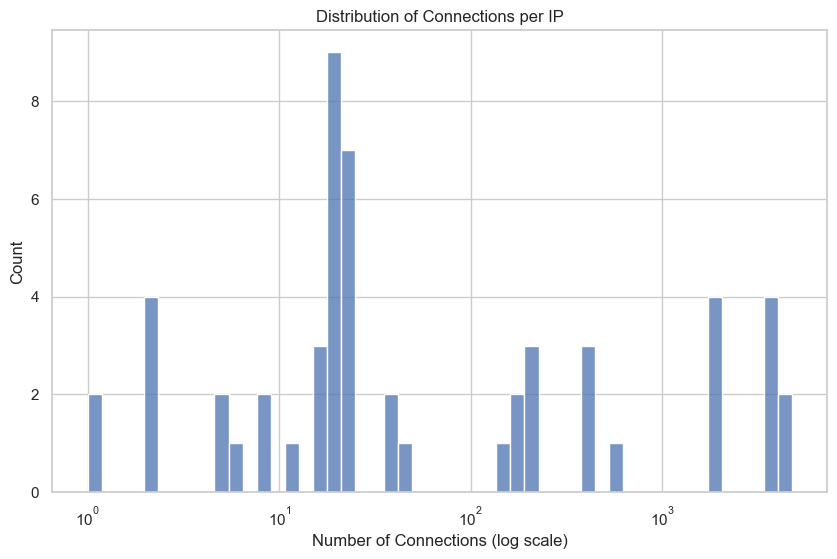

In [ ]:
#Distribution of connections per IP
ip_counts = df1["id.orig_h"].value_counts()

sns.histplot(ip_counts, bins=50, log_scale=True)
plt.title("Distribution of Connections per IP")
plt.xlabel("Number of Connections (log scale)")
plt.show()

<Axes: xlabel='id.resp_p'>

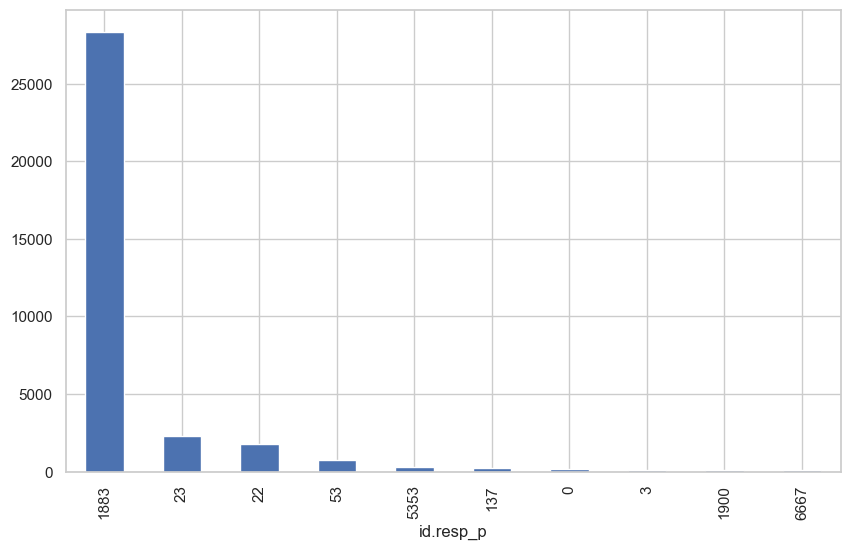

In [ ]:
# Top 10 most targeted destination ports
df1['id.resp_p'].value_counts().head(10).plot(kind='bar')


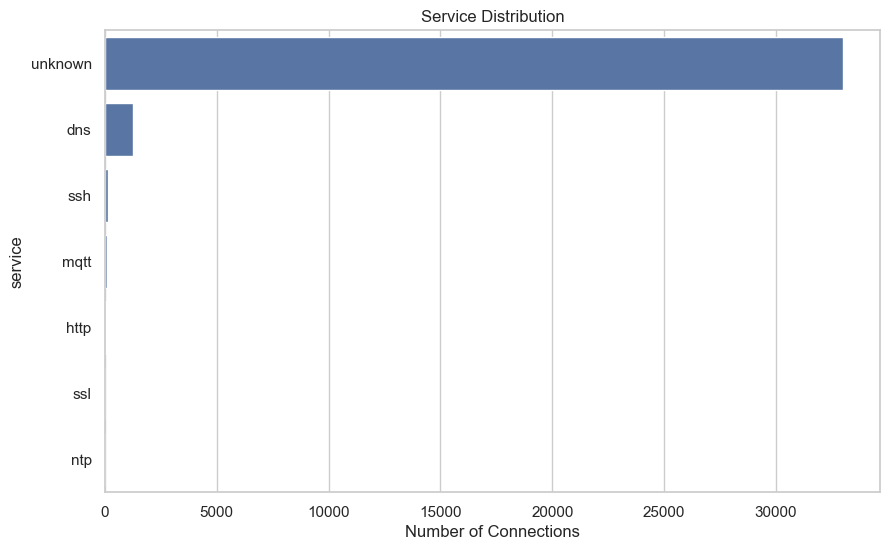

In [ ]:
#Service distribution
top_services = df1["service"].value_counts()

sns.barplot(x=top_services.values, y=top_services.index)
plt.title("Service Distribution")
plt.xlabel("Number of Connections")
plt.show()

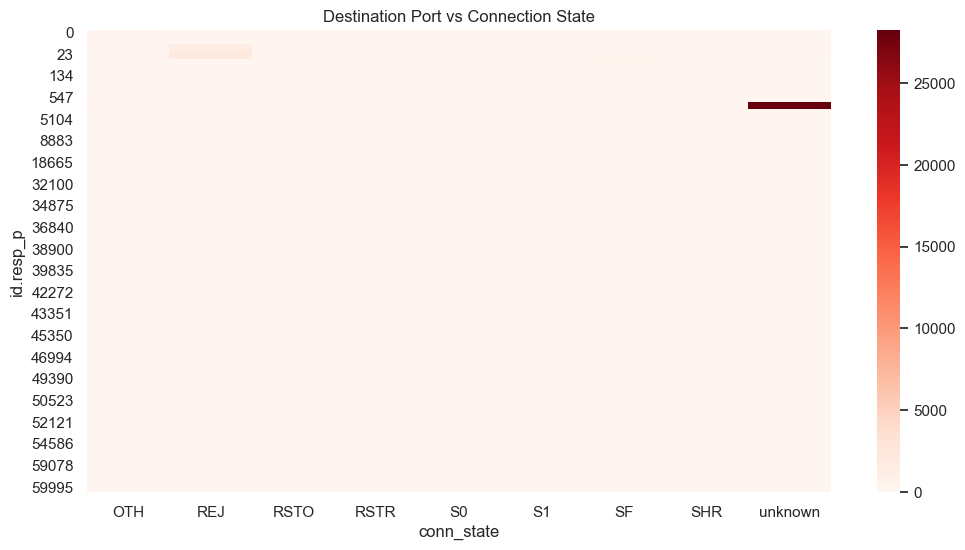

In [ ]:
#Port vs connection state heatmap
pivot = pd.crosstab(df1["id.resp_p"], df1["conn_state"])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Reds")
plt.title("Destination Port vs Connection State")
plt.show()

Index(['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
       'proto', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state',
       'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts',
       'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'ip_proto', 'service',
       'pcap_id', 'device_type', 'log_type', 'trans_depth', 'method', 'host',
       'uri', 'version', 'request_body_len', 'response_body_len',
       'status_code', 'status_msg', 'tags', 'resp_fuids', 'resp_mime_types',
       'from_client', 'retain', 'qos', 'status', 'topic', 'payload',
       'payload_len', 'auth_attempts', 'client', 'server', 'cipher_alg',
       'mac_alg', 'compression_alg', 'kex_alg', 'host_key_alg', 'host_key',
       'auth_success', 'hour', 'day_of_week', 'is_night', 'time_diff',
       'in_burst', 'burst_count', 'is_suspicious_state', 'suspicion_score',
       'sensitive_port_targeted'],
      dtype='object')

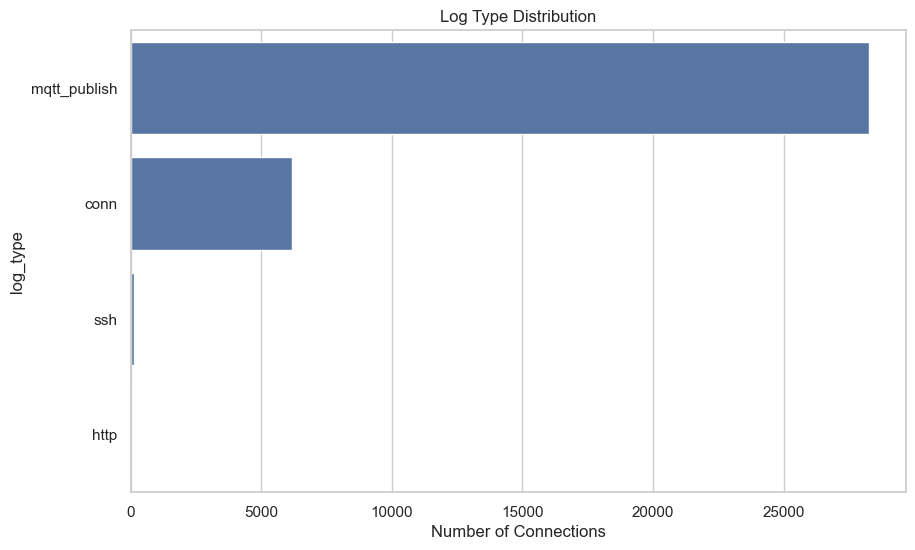

In [ ]:
#log type distribution
top_services = df1["log_type"].value_counts()

sns.barplot(x=top_services.values, y=top_services.index)
plt.title("Log Type Distribution")
plt.xlabel("Number of Connections")
plt.show()

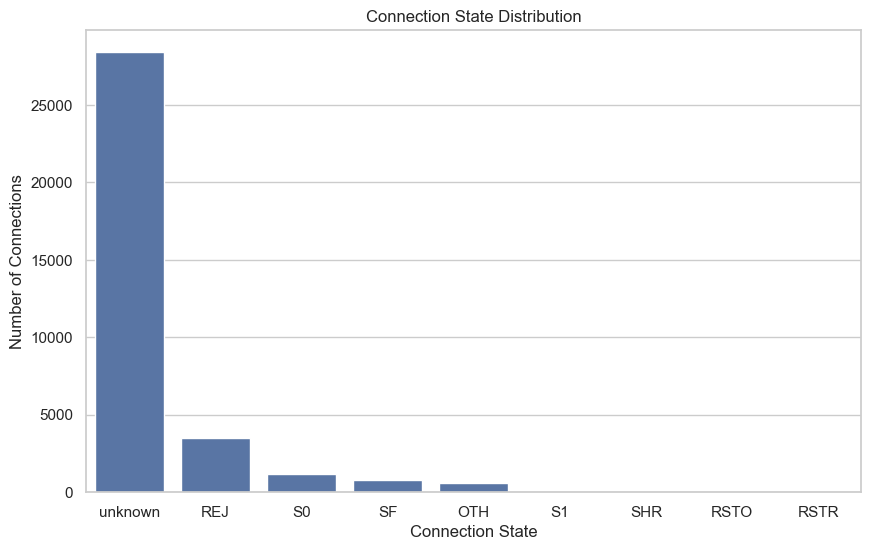

In [ ]:
#Connection state analysis (conn_state)
conn_state_counts = df1["conn_state"].value_counts()

sns.barplot(x=conn_state_counts.index, y=conn_state_counts.values)
plt.title("Connection State Distribution")
plt.xlabel("Connection State")
plt.ylabel("Number of Connections")
plt.show()

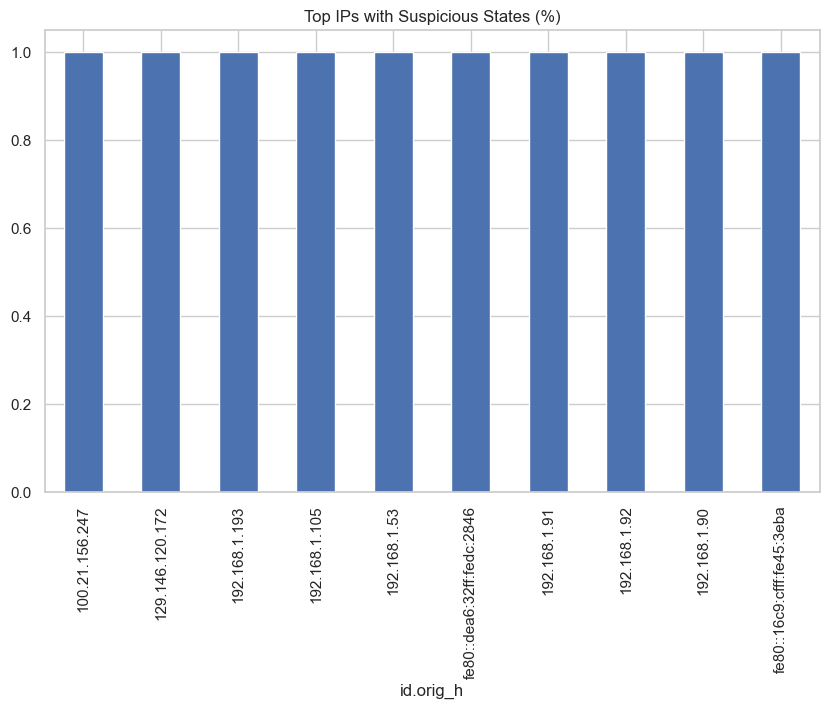

In [ ]:
if 'conn_state' in df1.columns:
    # suspicious states for brute force
    suspicious_states = ['REJ', 'RST', 'S0', 'OTH']
    df1['is_suspicious_state'] = df1['conn_state'].isin(suspicious_states).astype(int)

    # Percentage of suspicious states per IP
    state_by_ip = df1.groupby('id.orig_h')['is_suspicious_state'].mean().sort_values(ascending=False)
    state_by_ip.head(10).plot(kind='bar', title='Top IPs with Suspicious States (%)')

In [ ]:
import plotly.io as pio
# Use the VS Code renderer so the figure appears inside VS Code Jupyter/Notebook view
pio.renderers.default = "vscode"
df1['is_suspicious_state'] = df1['conn_state'].isin(suspicious_states).astype(int)
fig = px.timeline(
    df1[df1['is_suspicious_state'] == 1],
    x_start='ts',
    x_end='ts',
    y='id.orig_h',
    color='id.resp_p',
    hover_data=['conn_state', 'service'],
    title='Timeline of Suspicious Events by Source IP'
)

fig.update_yaxes(automargin=True)  
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

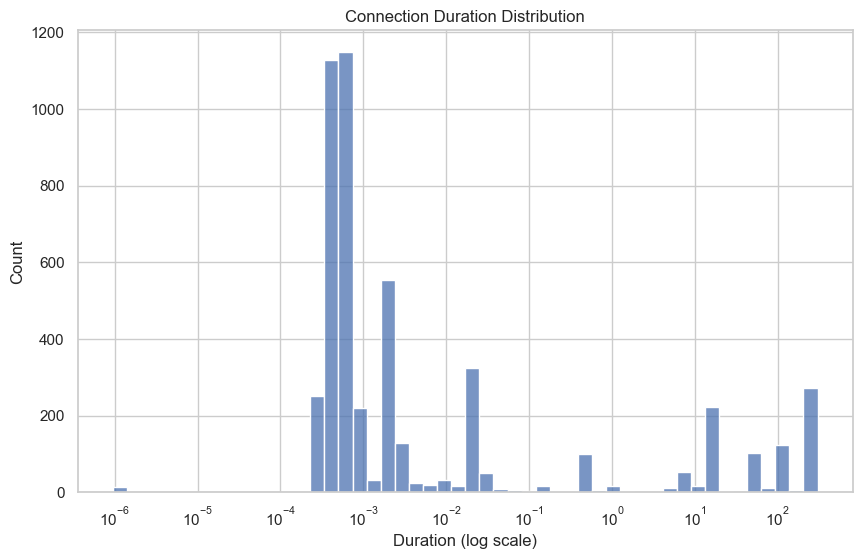

In [ ]:
#Connection duration distribution
sns.histplot(df1["duration"], bins=50, log_scale=True)
plt.title("Connection Duration Distribution")
plt.xlabel("Duration (log scale)")
plt.show()

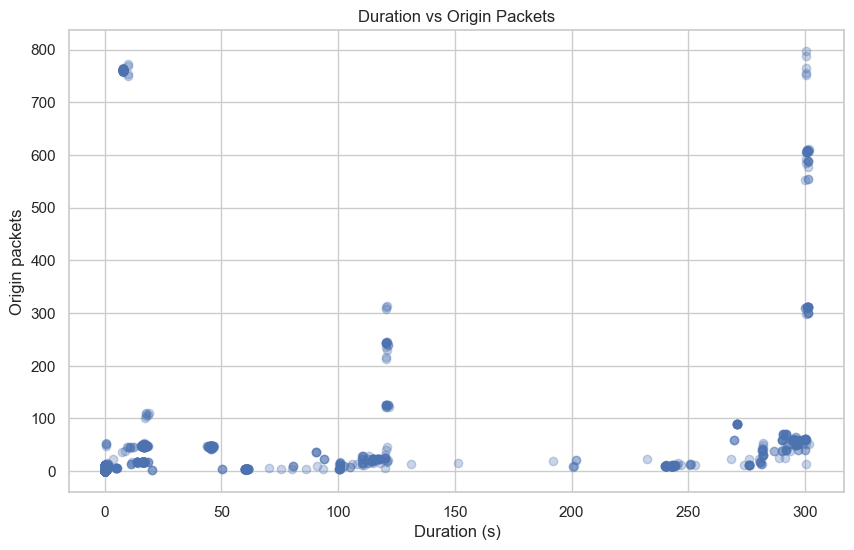

In [ ]:
plt.scatter(df1['duration'], df1['orig_pkts'], alpha=0.3)
plt.xlabel("Duration (s)")
plt.ylabel("Origin packets")
plt.title("Duration vs Origin Packets")
plt.show()
#Brute force → few packets over long duration

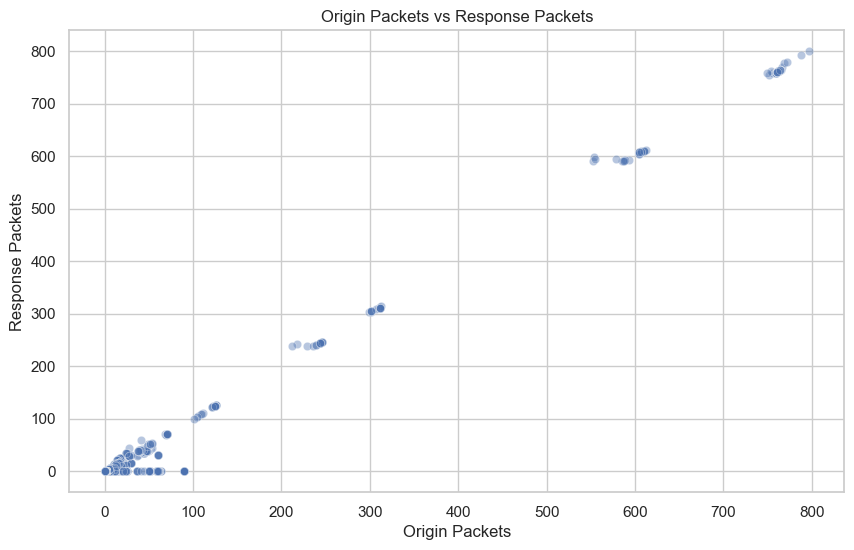

In [ ]:
#Sent packets vs received packets
sns.scatterplot(
    x=df1["orig_pkts"],
    y=df1["resp_pkts"],
    alpha=0.4
)

plt.title("Origin Packets vs Response Packets")
plt.xlabel("Origin Packets")
plt.ylabel("Response Packets")
plt.show()

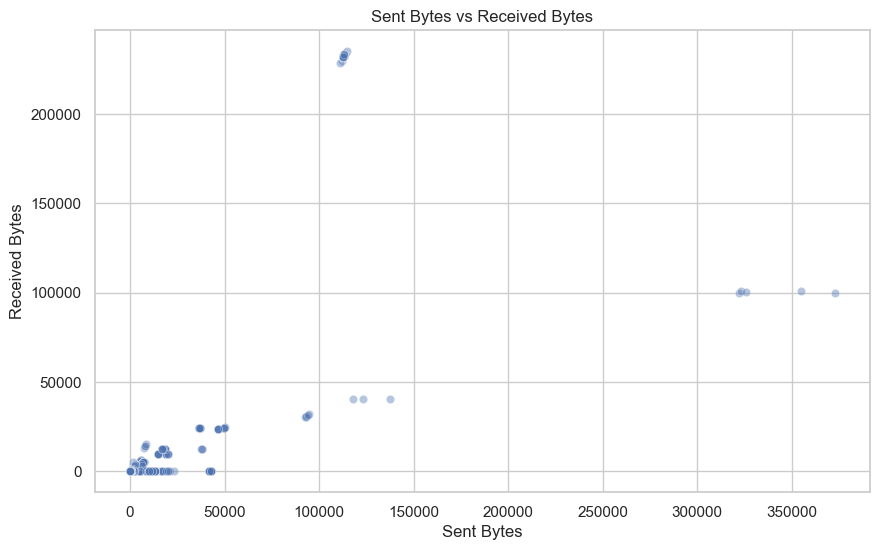

In [ ]:
#Sent bytes vs received bytes
sns.scatterplot(
    x=df1["orig_ip_bytes"],
    y=df1["resp_ip_bytes"],
    alpha=0.4
)

plt.title("Sent Bytes vs Received Bytes")
plt.xlabel("Sent Bytes")
plt.ylabel("Received Bytes")
plt.show()

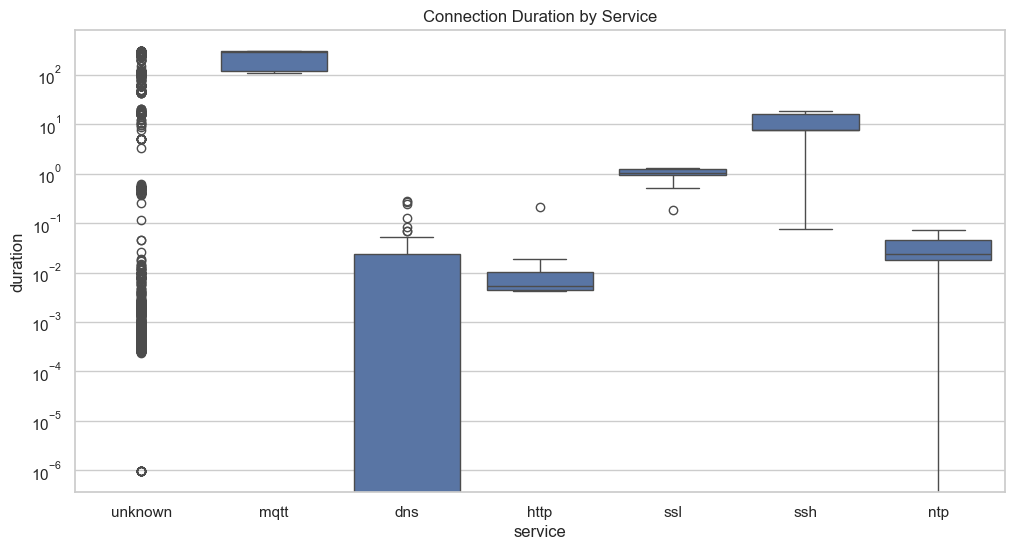

In [ ]:
#Duration by service (boxplot)
plt.figure(figsize=(12,6))
sns.boxplot(x="service", y="duration", data=df1)
plt.yscale("log")
plt.title("Connection Duration by Service")
plt.show()

In [ ]:
# Hourly activity per source IP
df1.groupby(['id.orig_h', 'hour']).size().unstack(fill_value=0)

hour,3,12,18,20
id.orig_h,,,,
100.21.156.247,2,2,1,0
129.146.120.172,1,3,0,1
192.168.1.1,191,74,148,200
192.168.1.10,1543,928,784,1507
192.168.1.100,134,1636,1902,393
192.168.1.101,6,3,2,6
192.168.1.102,5,4,2,7
192.168.1.103,5,3,2,7
192.168.1.104,5,4,2,7


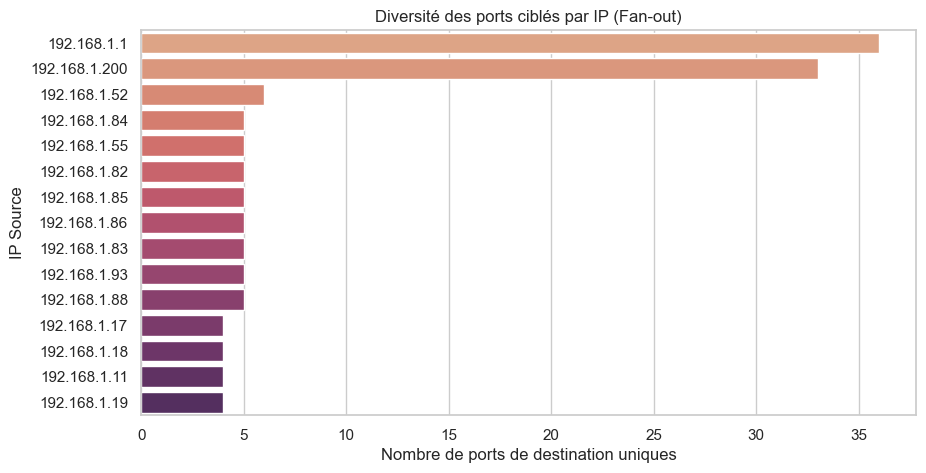

In [ ]:
# Number of unique destination ports contacted by each source IP.”**
port_diversity = df1.groupby('id.orig_h')['id.resp_p'].nunique().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=port_diversity.values, y=port_diversity.index, palette='flare')
plt.title('Diversité des ports ciblés par IP (Fan-out)')
plt.xlabel('Nombre de ports de destination uniques')
plt.ylabel('IP Source')
plt.show()

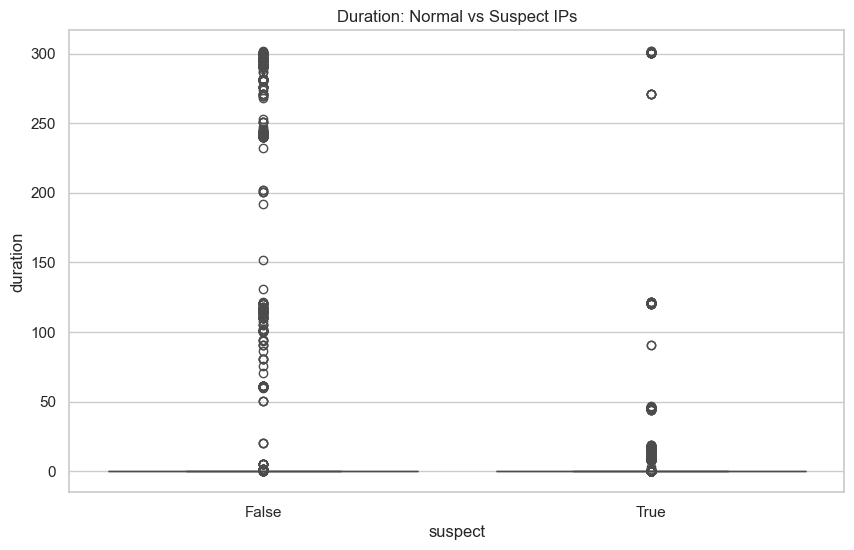

In [ ]:
# Identify suspect IPs based on connection counts
df1['suspect'] = df1['id.orig_h'].map(
    df1['id.orig_h'].value_counts() > 500
)

sns.boxplot(x='suspect', y='duration', data=df1)
plt.title("Duration: Normal vs Suspect IPs")
plt.show()

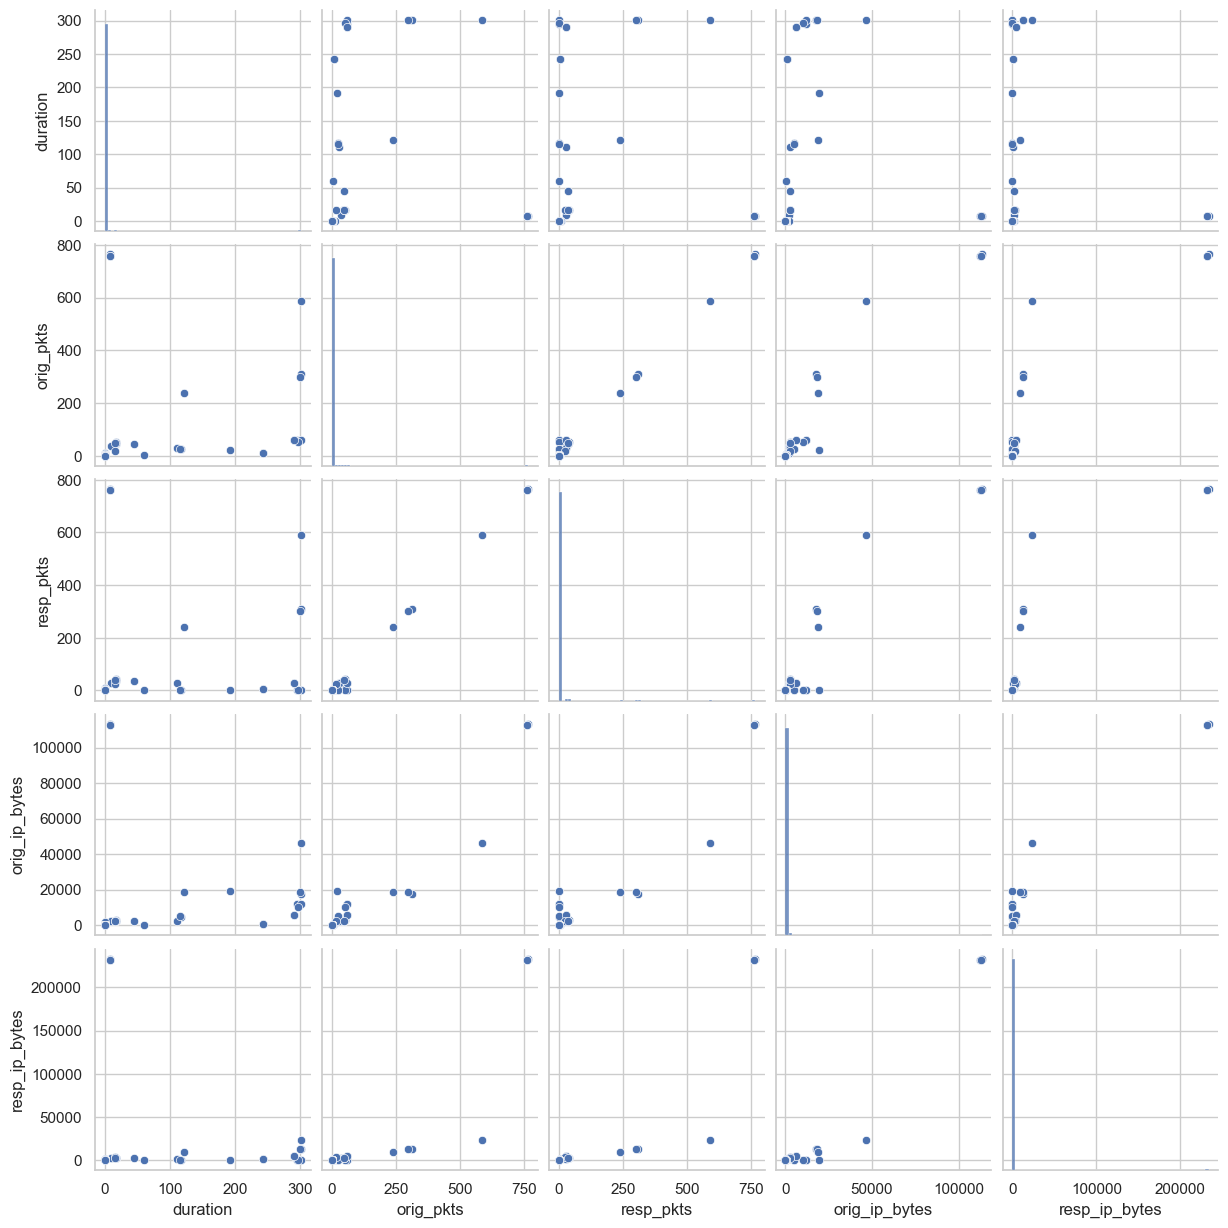

In [ ]:
#Pairplot (sampled for performance)
sample_df = df1[[
    "duration",
    "orig_pkts",
    "resp_pkts",
    "orig_ip_bytes",
    "resp_ip_bytes"
]].sample(1000)

sns.pairplot(sample_df)
plt.show()

In [ ]:
# Count attempts within short time windows
df1 = df.sort_values(['id.orig_h', 'ts'])
df1['time_diff'] = df1.groupby('id.orig_h')['ts'].diff().dt.total_seconds()

# Burst = multiple attempts within < 2 seconds
df1['in_burst'] = (df1['time_diff'] < 2).astype(int)
df1['burst_count'] = df1.groupby('id.orig_h')['in_burst'].rolling(window=10, min_periods=1).sum().values

# IPs with the highest burst counts
top_burst_ips = df1.groupby('id.orig_h')['burst_count'].max().sort_values(ascending=False).head(10)
print(top_burst_ips)

id.orig_h
192.168.1.10     10.0
192.168.1.1      10.0
192.168.1.100    10.0
192.168.1.12     10.0
192.168.1.13     10.0
192.168.1.14     10.0
192.168.1.193    10.0
192.168.1.18     10.0
192.168.1.17     10.0
192.168.1.11     10.0
Name: burst_count, dtype: float64


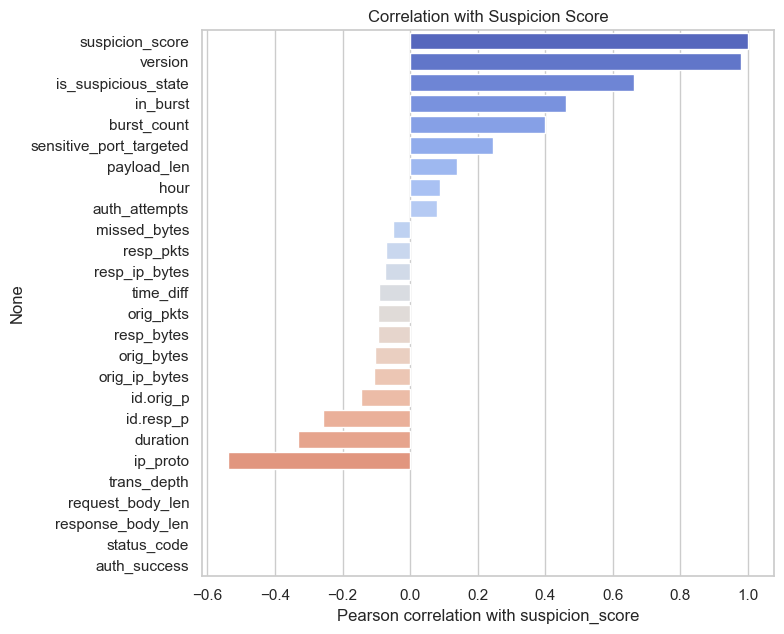

In [ ]:
# Features de suspicion 
SENSITIVE_PORTS = {22, 23, 1883}

# create sensitive_port_targeted if missing
df1['sensitive_port_targeted'] = df1['id.resp_p'].isin(SENSITIVE_PORTS).astype(int)

# ensure is_suspicious_state exists
suspicious_states = ['REJ', 'RST', 'S0', 'OTH']
if 'is_suspicious_state' not in df1.columns:
    if 'conn_state' in df1.columns:
        df1['is_suspicious_state'] = df1['conn_state'].isin(suspicious_states).astype(int)
    else:
        df1['is_suspicious_state'] = 0

# ensure in_burst exists (compute if needed)
if 'in_burst' not in df1.columns:
    if {'ts', 'id.orig_h'}.issubset(df1.columns):
        tmp = df1.sort_values(['id.orig_h', 'ts']).copy()
        tmp['time_diff'] = tmp.groupby('id.orig_h')['ts'].diff().dt.total_seconds()
        tmp['in_burst'] = (tmp['time_diff'] < 2).astype(int)
        df1 = tmp
    else:
        df1['in_burst'] = 0

# compute suspicion score (weights: suspicious state 40%, burst 30%, sensitive port 30%)
df1['suspicion_score'] = (
    df1['is_suspicious_state'].astype(float) * 0.4 +
    df1['in_burst'].astype(float) * 0.3 +
    df1['sensitive_port_targeted'].astype(float) * 0.3
).clip(0, 1)

# correlation with other numeric features
num_cols = df1.select_dtypes(include=[np.number])

# compute correlation of numeric columns with suspicion_score
corr_with_suspicion = num_cols.corr()['suspicion_score'].sort_values(ascending=False)

# Plot as a bar chart (heatmap expects 2D input; a 1D Series causes shape errors)
plt.figure(figsize=(8, max(4, len(corr_with_suspicion) * 0.25)))
sns.barplot(x=corr_with_suspicion.values, y=corr_with_suspicion.index, palette="coolwarm")
plt.xlabel("Pearson correlation with suspicion_score")
plt.title("Correlation with Suspicion Score")
plt.tight_layout()
plt.show()

During the Exploratory Data Analysis (EDA) phase, we assessed the quality, completeness, and suitability of the dataset for brute force attack detection. To reduce noise and ensure data reliability, we removed all columns exhibiting more than 99.9% missing values and retained a subset of core features relevant to network attack characterization. These features include timestamps, source IP addresses, destination ports, application-layer services, connection states, packet counts, traffic volume metrics, and derived temporal attributes. Missing numerical values were replaced with zeros to represent incomplete or failed connection attempts, while missing categorical values were encoded as unknown. Timestamps were converted to datetime format, events were sorted chronologically, and temporal features such as hour of day, day of week, and night-time indicators were extracted. This preprocessing pipeline resulted in a clean, consistent, and structured dataset suitable for behavioral modeling and attack detection.

The behavioral analysis of network traffic reveals strong and consistent indicators of automated brute force activity. Temporal analyses expose high-intensity bursts of connection attempts occurring within short time windows, often exceeding thousands of connections per minute, followed by intervals of inactivity—an on–off pattern characteristic of scripted attacks and bot-driven behavior. Statistical distributions of connection duration and traffic volume are heavily skewed toward near-zero values, reflecting rapid and repetitive failed authentication attempts. Moreover, the traffic is highly concentrated on sensitive and commonly targeted services, particularly MQTT (Port 1883) and remote access protocols such as SSH (Port 22) and Telnet (Port 23). A limited number of source IP addresses are responsible for the majority of connection attempts, indicating coordinated and non-human activity. Additionally, a significant proportion of sessions terminate in suspicious or incomplete connection states (e.g., REJ, RST, S0, OTH), further reinforcing the presence of systematic authentication failures. Collectively, these patterns provide strong empirical evidence that the dataset is dominated by automated brute force attack behavior rather than legitimate network usage, thereby justifying its use for the development and evaluation of brute force detection models.